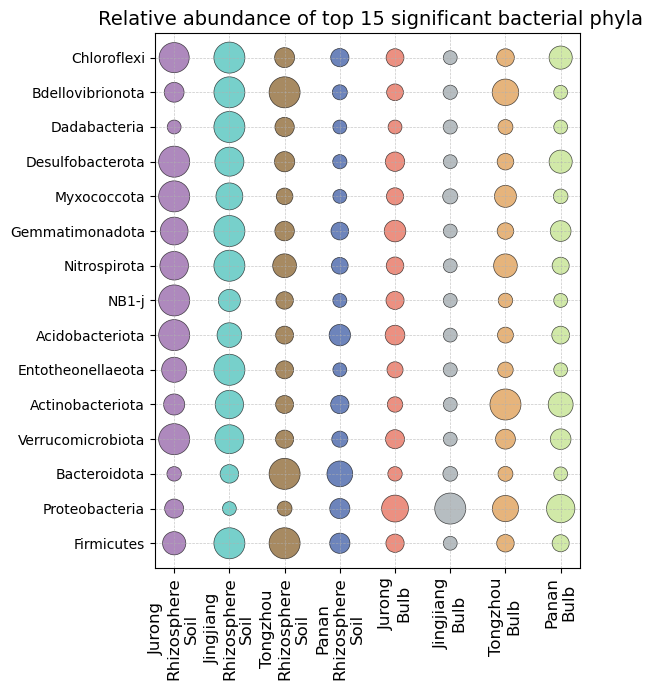

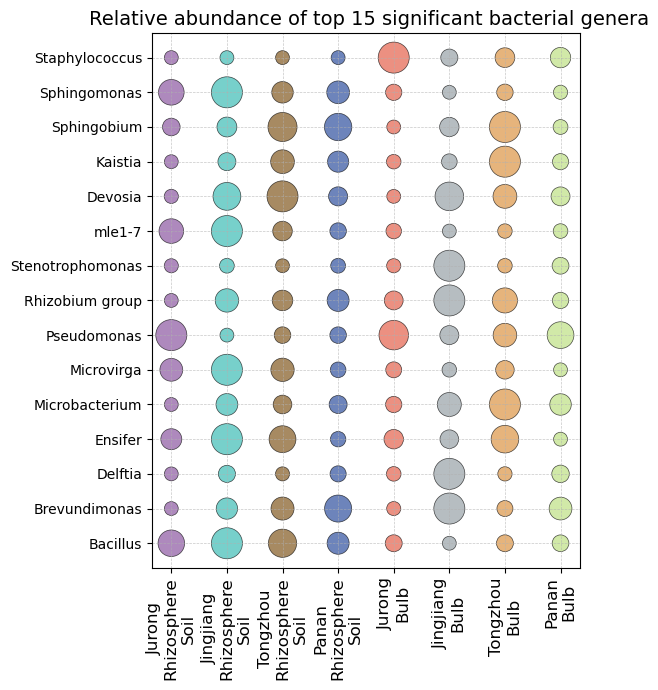

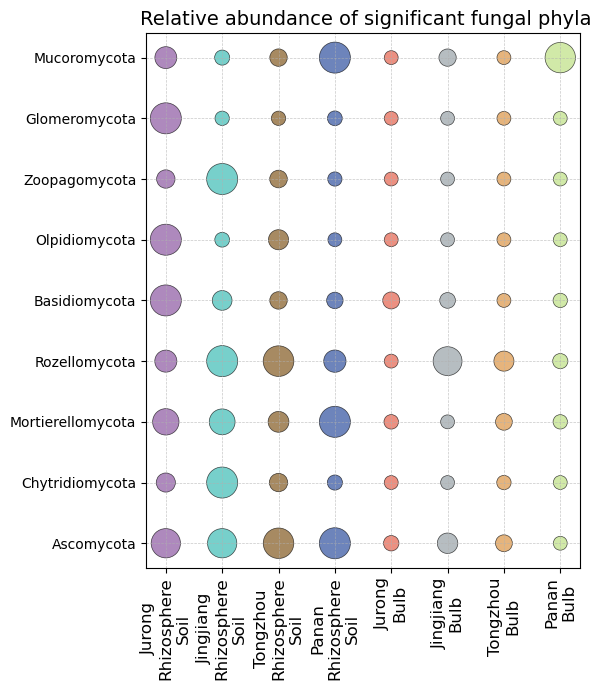

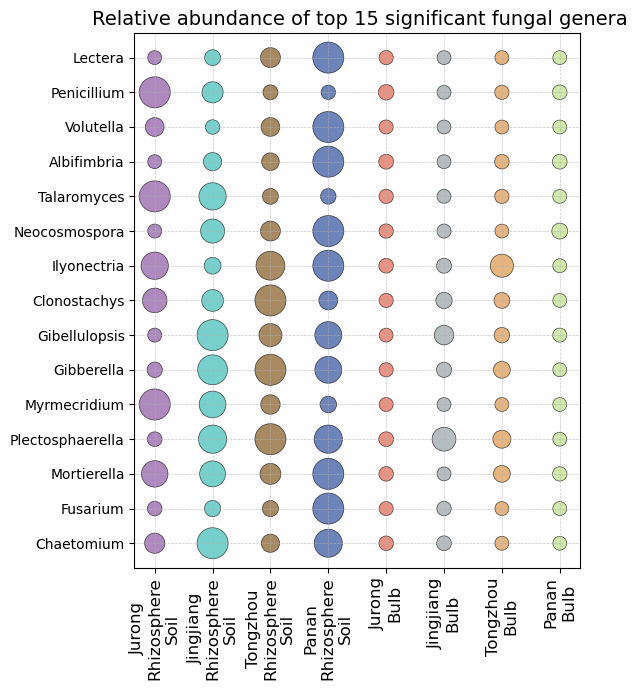

In [1]:
# 参考构建环境https://github.com/leaph-lab/USsoil16S_MS/tree/main
#conda install openpyxl
#图2d及附图2差异
import pandas as pd
from collections import defaultdict
from scipy.stats import kruskal
import numpy as np
import statsmodels.stats.multitest as smt
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os # 确保 os 库已导入，用于路径操作和目录创建
from scipy.stats import gaussian_kde
import warnings
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from matplotlib.patches import Ellipse
from scipy.stats import mannwhitneyu
import statsmodels.stats.multitest as smt
# from statannotations.Annotator import Annotator
from sklearn.metrics import pairwise_distances
from mpl_toolkits.basemap import Basemap
from collections import OrderedDict
import pandas as pd
from skbio.diversity import alpha_diversity
import numpy as np
from skbio.stats import subsample_counts


def bubble_plot(df, sig_var, plot_title, pdf_file):
    """
    创建气泡图，显示显著细菌组在不同生态系统中的中位丰度。
    气泡大小表示平均丰度，颜色表示生态系统类型。

    参数:
        df (DataFrame): 包含生态系统数据和细菌组丰度的 DataFrame。
                        应包含 'Group' 列和细菌组的丰度列。
        sig_var (dict): 显著变量及其校正 p-值的字典。用于确定要绘制的细菌组。
        plot_title (str): 图表的标题。
        pdf_file (str): 保存图表的 PDF 文件名（将保存到 '/mnt/d/study/master/Main_Figure_tables/Figure_2/f_' 目录下）。

    返回:
        None: 显示并保存气泡图。
    """
    # 从显著变量字典中获取所有需要绘制的细菌组（列名）
    sig_columns = list(sig_var.keys())

    # 排除 'Group' 列中值为 "unknown"（不区分大小写）的行
    # 这确保了未知生态系统的样本不会包含在绘图中
    df = df[df['Group'].str.lower() != "unknown"]

    # 获取 DataFrame 中所有唯一的生态系统类型
    groups = df['Group'].unique()

    # 初始化列表，用于存储每个细菌组在每个生态系统中的平均丰度
    abundance_values = []
    # (max_abundance_values 在原代码中计算但未使用，在此保留以示完整性，实际可忽略)
    max_abundance_values = []

    # 循环遍历每个显著细菌组和每个生态系统
    for col in sig_columns:
        for eco in groups:
            # 计算当前生态系统中，当前细菌组的平均丰度
            # 注意：注释写的是“中位丰度”，但代码实际使用的是 `.mean()`
            median_abundance = df[df['Group'] == eco][col].mean()
            # 计算最大丰度（未使用）
            max_abundance = df[df['Group'] == eco][col].max()
            
            # 将计算出的丰度值添加到列表中
            abundance_values.append(median_abundance)
            max_abundance_values.append(max_abundance)

    # 构建一个用于绘图的 Pandas DataFrame
    # 'Bacterial Group' 列重复显著细菌组的名称
    # 'Group' 列平铺生态系统名称
    # 'Abundance' 列存储对应的平均丰度
    plot_df = pd.DataFrame({
        'Bacterial Group': np.repeat(sig_columns, len(groups)),
        'Group': np.tile(groups, len(sig_columns)),
        'Abundance': abundance_values,
        'Max Abundance': max_abundance_values # 再次强调，此列未使用
    })

    # 归一化气泡大小：将 'Abundance' 值映射到一个可视化的气泡尺寸范围
    min_size, max_size = 100, 500 # 定义气泡的最小和最大尺寸
    for group in plot_df['Bacterial Group'].unique():
        # 获取当前细菌组的所有数据行索引
        group_indices = plot_df['Bacterial Group'] == group
        # 计算当前细菌组的最小和最大丰度
        min_abundance = plot_df.loc[group_indices, 'Abundance'].min()
        max_abundance = plot_df.loc[group_indices, 'Abundance'].max()

        # 如果当前细菌组的所有丰度值都相同（即 max - min = 0），则将气泡大小设为最大值
        if max_abundance - min_abundance == 0:
             plot_df.loc[group_indices, 'Bubble Size'] = max_size
        else:
            # 否则，按比例将丰度映射到气泡尺寸范围
            plot_df.loc[group_indices, 'Bubble Size'] = (plot_df.loc[group_indices, 'Abundance'] - min_abundance) / (max_abundance - min_abundance)
            plot_df.loc[group_indices, 'Bubble Size'] = plot_df.loc[group_indices, 'Bubble Size'] * (max_size - min_size) + min_size

        # 确保气泡大小不为零。如果归一化后仍为0（通常不会发生），则设为最小尺寸
        plot_df.loc[group_indices, 'Bubble Size'] = plot_df.loc[group_indices, 'Bubble Size'].replace(0, min_size)

    # 定义生态系统类型的颜色映射，确保每个生态系统有固定颜色
    class_colors = {
        "JRG": "#8C57A2FF",
        "JJG": "#3EBCB6",
        "TZG": "#82581FFF",
        "PAG": "#2F509EFF",
        "JRN": "#E5614CFF",
        "JJN": "#97A1A7FF",
        "TZN": "#DC9445FF",
        "PAN": "#bee183"
    }

    # 创建 Matplotlib 图形
    plt.figure(figsize=(6, 7)) # 设置图表尺寸
# 遍历每个细菌组，分别绘制其在不同生态系统中的气泡
    # 创建斜体标签的列表
    #italic_cleaned_sig_columns_for_plot = [f"$\it{{{col}}}$" for col in sig_columns]
    #plt.yticks(ticks=np.arange(len(sig_columns)), labels=italic_cleaned_sig_columns_for_plot, fontsize=10)

    for group in plot_df['Bacterial Group'].unique():
        group_df = plot_df[plot_df['Bacterial Group'] == group]
        # 根据生态系统类型获取对应的颜色
        colors = [class_colors[eco] for eco in group_df['Group']]
        # 绘制散点图，通过 's' 参数控制气泡大小，'c' 参数控制颜色
        plt.scatter(group_df['Group'], group_df['Bacterial Group'],
                    s=group_df['Bubble Size'], c=colors, alpha=0.7, # alpha 设置透明度
                    label=group, edgecolors='black', linewidth=0.5) # 气泡边缘颜色和宽度

    #标签映射字典
    habitat_labeller = {
        "JRG": "Jurong\nRhizosphere\nSoil",
        "JJG": "Jingjiang\nRhizosphere\nSoil",
        "TZG": "Tongzhou\nRhizosphere\nSoil",
        "PAG": "Panan\nRhizosphere\nSoil",
        "JRN": "Jurong\nBulb",
        "JJN": "Jingjiang\nBulb",
        "TZN": "Tongzhou\nBulb",
        "PAN": "Panan\nBulb"
    }

    # 根据 groups 生成新的标签列表
    new_x_labels = [habitat_labeller[group] for group in groups]

    #设置新标签和垂直旋转
    plt.xticks(
        ticks=groups, # 保持原始的组名作为刻度位置
        labels=new_x_labels,        # 使用新的、多行的标签
        fontsize=12,
        rotation=90,                # 旋转 90 度，使标签垂直
        ha='center'                 # 水平对齐方式改为 'center'，让标签的中心点对齐刻度
    )
    plt.xlabel('') # 移除 X 轴标签
    plt.ylabel('') # 移除 Y 轴标签
    plt.title(plot_title, size=14) # 设置图表标题
    # 添加网格线，增加可读性
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # 创建自定义图例，显示生态系统类型及其对应颜色
    #handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
    #                      markerfacecolor=class_colors[label], markersize=10)
    #           for label in groups]
    # 将图例放置在图表外部的右上角
    #plt.legend(handles=handles, title="Groups", bbox_to_anchor=(1.05, 1), loc='upper left')

    # 保存图表为 Png 文件
    plt.savefig('/mnt/d/study/master/Main_Figure_tables/Figure_2/' + pdf_file, format='png', bbox_inches='tight', dpi=600)
    # 自动调整图表布局，防止元素重叠
    plt.tight_layout()
    plt.show() # 显示图表

# 辅助函数：FDR 校正
def fdr_sig(p_values_dict, alpha=0.05):
    """
    对p值进行Benjamini-Hochberg FDR校正，并返回显著的变量。

    Args:
        p_values_dict (dict): 包含变量名和p值的字典。
        alpha (float): 显著性水平。

    Returns:
        dict: 包含经过FDR校正后显著的变量及其校正后p值的字典。
    """
    if not p_values_dict:
        return {}

    # 将字典转换为列表，以便于处理
    variables = list(p_values_dict.keys())
    p_values = list(p_values_dict.values())

    # 移除 NaN 值，因为 FDR 校正不支持
    # 记录 NaN 值的位置，以便在结果中忽略它们
    non_nan_indices = [i for i, p in enumerate(p_values) if not pd.isna(p)]
    p_values_clean = [p_values[i] for i in non_nan_indices]
    variables_clean = [variables[i] for i in non_nan_indices]

    if not p_values_clean:
        return {} # 如果所有p值都是NaN，则没有显著变量

    # 执行Benjamini-Hochberg FDR校正
    # reject_fdr: 布尔数组，指示每个p值是否通过FDR校正
    # pvals_corrected_fdr: 经过FDR校正后的p值
    reject_fdr, pvals_corrected_fdr, _, _ = smt.multipletests(
        p_values_clean,
        alpha=alpha,
        method='fdr_bh' # Benjamini-Hochberg方法
    )

    sig_vars = {}
    for i, var_name in enumerate(variables_clean):
        if reject_fdr[i]: # 如果通过FDR校正
            sig_vars[var_name] = pvals_corrected_fdr[i]

    return sig_vars


# 主要函数：Kruskal-Wallis 检验
def KW_test(df, group_col='Group', alpha=0.05):
    """
    对DataFrame中的每个数值列执行Kruskal-Wallis检验，
    并对p值进行FDR校正，返回显著的变量。

    Args:
        df (pd.DataFrame): 包含数值特征列和分组列的DataFrame。
        group_col (str): DataFrame中用于分组的列名。
        alpha (float): 显著性水平。

    Returns:
        tuple: (dict, dict)
            - 第一个字典包含经过FDR校正后显著的变量及其校正后p值。
            - 第二个字典包含所有变量的原始p值。
    """
    p_values = {}
    # 获取唯一的组名
    unique_groups = df[group_col].dropna().unique()

    # 遍历DataFrame中的所有数值列
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]) and column != group_col:
            # 提取每个组的数据
            groups_data = []
            valid_groups_found = 0
            for group_name in unique_groups:
                group_values = df[df[group_col] == group_name][column].dropna().tolist()
                # 检查组内是否有足够的变异性（至少有两个不同的值）
                if len(set(group_values)) >= 2:
                    groups_data.append(group_values)
                    valid_groups_found += 1
                elif len(group_values) > 0: # 组内只有一个值，但不是空的
                     # 如果组内只有一个值，且所有组数据加起来少于两个有效组，则可能无法进行检验
                    pass # 忽略无变异的组，但如果所有组都无变异，kruskal会失败

            # Kruskal-Wallis检验需要至少两个非空且有变异的组
            if valid_groups_found >= 2:
                # 确保所有用于检验的列表不是空的
                groups_data_filtered = [g for g in groups_data if len(g) > 0]
                if len(groups_data_filtered) >= 2:
                    try:
                        stat, p = kruskal(*groups_data_filtered)
                        p_values[column] = p
                    except ValueError as e:
                        # 捕获可能由于数据问题导致的ValueError
                        # print(f"警告: 对列 '{column}' 执行Kruskal-Wallis检验时发生错误: {e}. p值设置为NaN。")
                        p_values[column] = np.nan # 无法计算，设置为NaN
                else:
                    # 不足两个有效组进行检验
                    p_values[column] = np.nan # 设置为NaN，因为它无法被有效检验
            else:
                # 不足两个有变异的组进行检验，无法计算p值
                p_values[column] = np.nan # 设置为NaN


    # 对p值进行FDR校正
    sig_vars = fdr_sig(p_values, alpha=alpha)

    return sig_vars, p_values

def save_stats_to_csvs(df, sig_var, pval, filename_prefix):
    """
    保存显著变量的统计摘要（均值、众数、中位数、最大值、最小值）到 CSV 文件。

    参数:
        df (DataFrame): 包含要汇总的数据的 DataFrame。
        sig_var (dict): 包含显著变量及其校正 p 值的字典。
        pval (dict): 包含每个变量原始 p 值的字典。
        filename_prefix (str): 用于保存统计摘要的 CSV 文件名的前缀。

    返回:
        tuple: 包含均值、众数、中位数、最大值和最小值摘要的 DataFrames 元组。
    """

    sig_var = {k: v for k, v in sig_var.items() if k.lower() != "unknown"}

    df = df[df['Group'].str.lower() != "unknown"].copy() # 加上 .copy() 避免 SettingWithCopyWarning

    sig_columns = list(sig_var.keys())
    ecosystems = df['Group'].unique()

    mean_df = pd.DataFrame(index=sig_columns, columns=ecosystems)
    mode_df = pd.DataFrame(index=sig_columns, columns=ecosystems)
    median_df = pd.DataFrame(index=sig_columns, columns=ecosystems)
    max_df = pd.DataFrame(index=sig_columns, columns=ecosystems)
    min_df = pd.DataFrame(index=sig_columns, columns=ecosystems)

    for col in sig_columns:
        for eco in ecosystems:
            # 确保列存在于 DataFrame 中，避免 KeyError
            if col in df.columns:
                filtered_df = df[df['Group'] == eco][col]
                mean_df.loc[col, eco] = filtered_df.mean()
                mode_df.loc[col, eco] = filtered_df.mode().tolist()
                median_df.loc[col, eco] = filtered_df.median()
                max_df.loc[col, eco] = filtered_df.max()
                min_df.loc[col, eco] = filtered_df.min()
            else:
                # 如果列不存在，可以根据需要设置 NaN 或 0，或发出警告
                # 这里设置为 NaN
                mean_df.loc[col, eco] = None
                mode_df.loc[col, eco] = None
                median_df.loc[col, eco] = None
                max_df.loc[col, eco] = None
                min_df.loc[col, eco] = None


    for stat_df in [mean_df, mode_df, median_df, max_df, min_df]:
        stat_df['adjusted_p_value'] = stat_df.index.map(sig_var)
        stat_df['p_value'] = stat_df.index.map(
            lambda x: pval[x][0] if x in pval and isinstance(pval[x], list) and len(pval[x]) > 0 else None
        )

    #  保存 DataFrames 到 CSV 
    # 定义与气泡图相同的输出目录
    output_directory = '/mnt/d/study/master/Main_Figure_tables/Figure_2/sig/'

    # 检查并创建目录，如果它不存在
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        print(f"已创建目录: {output_directory}")

    # 使用 os.path.join() 构建完整的文件路径，更健壮
    mean_df.to_csv(os.path.join(output_directory, f'{filename_prefix}_mean.csv'))
    # mode_df.to_csv(os.path.join(output_directory, f'{filename_prefix}_mode.csv')) # 如果需要保存众数，请取消注释
    median_df.to_csv(os.path.join(output_directory, f'{filename_prefix}_median.csv'))
    max_df.to_csv(os.path.join(output_directory, f'{filename_prefix}_max.csv'))
    min_df.to_csv(os.path.join(output_directory, f'{filename_prefix}_min.csv'))

    return mean_df, mode_df, median_df, max_df, min_df

#  细菌差异 
# 读取包含分类信息的CSV文件
metadata = pd.read_csv("/mnt/d/study/master/metadata.tsv", sep='\t')
group_df = metadata.iloc[:, :2]
# 门 (Phylum) 水平分析 
# 读取门水平的丰度数据，并使用 `data_cleaner` 函数进行清洗和预处理
bacteria_ASV = pd.read_csv("/mnt/d/study/master/meiji/bacteria_ASV.csv", sep=",", header=0)
# 构建要选择的列名列表，包括 "ASV" 和所有的样本ID
sample_ids = metadata['Sample ID'].tolist()
columns_to_select = ["ASV"] + sample_ids
# 从 bacteria_ASV DataFrame 中选择指定的列
b_ASV = bacteria_ASV[columns_to_select]
# 将 'ASV' 列设置为 DataFrame 的索引 (行名)
b_ASV.set_index(keys="ASV", inplace=True)
#b_row_sums = b_ASV.sum(axis=1)
#b_ASV = b_ASV[b_row_sums >= 4]
b_tax = bacteria_ASV.iloc[:, 1:9].copy()
b_tax.set_index(keys="ASV", inplace=True)
# 构建筛选条件
#condition = (
#    b_tax['Genus'].str.contains("g__uncultured", flags=re.IGNORECASE, na=False) |
#    b_tax['Genus'].str.contains("g__unclassified", flags=re.IGNORECASE, na=False) |
#    b_tax['Genus'].str.contains("g__norank", flags=re.IGNORECASE, na=False)
#)
# 对条件取反，保留不包含这些字符串的行
#b_tax_df = b_tax[~condition].copy()
# 获取 b_tax_df 的索引（即过滤后的 ASV 名称）
#b_filtered_asv_names = b_tax_df.index
# 使用 Pandas 的 .isin() 方法进行筛选
#b_ASV = b_ASV[b_ASV.index.isin(b_filtered_asv_names)].copy()
len(b_ASV)
#抽平
#b_rarefaction_depth = b_ASV.sum(axis=0).min()
# 对每一行（一个样本）进行 rarefaction
#b_ASV_rarefied = b_ASV.apply(lambda col: pd.Series(
#    subsample_counts(col.values.astype(int), b_rarefaction_depth, replace=False,seed=42)
#), axis=0)
# 保留原列名
#b_ASV_rarefied.columns = b_ASV.columns
# 获取 b_ASV DataFrame 的所有 ASV 索引（即 ASV 名称列表）
#b_asvs_in_b_asv = b_ASV.index
# 使用 isin() 方法筛选 b_tax_df，只保留其索引存在于 asvs_in_b_asv 中的行
#b_tax_df = b_tax_df[b_tax_df.index.isin(b_asvs_in_b_asv)].copy()
# 合并丰度表和分类信息表
b_tax_df = b_tax
b_tax_reset_index = b_tax_df.reset_index() # 将 ASV 索引变为普通列
b_merged_phylum = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Phylum']], on='ASV', how='left')
b_merged_phylum.set_index('ASV', inplace=True)
# 去除 'p__' 前缀
b_merged_phylum['Phylum'] = b_merged_phylum['Phylum'].astype(str).str.replace("p__", "")
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Phylum' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Phylum 本身），只对数值列求和。
b_phylum_absolute = b_merged_phylum.groupby('Phylum').sum()
# 使用 .T 属性进行转置
b_phylum_absolute_transposed = b_phylum_absolute.T
b_data_phylum = b_phylum_absolute_transposed
b_data_phylum = b_data_phylum.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_phylum.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_phylum = pd.merge(b_data_phylum, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值
b_sig_phylum, b_pval_phylum = KW_test(b_taxa_phylum)
# 按照p值从小到大排序
b_sorted_sig_phylum = sorted(b_sig_phylum.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_phylum_dict = dict(b_sorted_sig_phylum[:b_top_n])
# 绘制显著门的平均相对丰度气泡图
# ' Relative abundance of significant bacterial phyla' 是图表的标题
# 'sig_phyla_groups.png' 是保存图表的文件名
bubble_plot(b_taxa_phylum, b_top_sig_phylum_dict, ' Relative abundance of top 15 significant bacterial phyla', 'sig_phyla_groups_bacteria.png')
# 注意：气泡大小在每个细菌组内部进行归一化，这意味着对于某个门，其在不同生态系统中的丰度差异决定了气泡大小。
# 保存显著属的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_phylum, b_sig_phylum, b_pval_phylum, "b_sig_phylum_group")

# 属 (Genus) 水平分析 
b_merged_genus = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Genus']], on='ASV', how='left')
b_merged_genus.set_index('ASV', inplace=True)
# 去除 'g__' 前缀
b_merged_genus['Genus'] = b_merged_genus['Genus'].astype(str).str.replace("g__", "")
# 定义一个字典来映射旧的Genus名称到新的组名
genus_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Genus，请在这里添加
    # "OldGenusName1": "NewGroupName1",
    # "OldGenusName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Genus' 列中的名称进行重命名
b_merged_genus['Genus'] = b_merged_genus['Genus'].map(genus_recode_map).fillna(b_merged_genus['Genus'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Genus' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Genus 本身），只对数值列求和。
b_genus_absolute = b_merged_genus.groupby('Genus').sum()
# 使用 .T 属性进行转置
b_genus_absolute_transposed = b_genus_absolute.T
b_data_genus = b_genus_absolute_transposed
b_data_genus = b_data_genus.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_genus.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_genus = pd.merge(b_data_genus, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_genus, b_pval_genus = KW_test(b_taxa_genus)
# 按照p值从小到大排序
b_sorted_sig_genus = sorted(b_sig_genus.items(), key=lambda item: item[1])
# 定义模糊属（Genus）的模式（不区分大小写）
ambiguous_patterns = re.compile(
    r"uncultured|unclassified|norank|chloroplast|mitochondria", 
    flags=re.IGNORECASE
)
# 过滤掉匹配模糊模式的属
b_filtered_sig_genus = {}
for genus, p_value in b_sorted_sig_genus:
    # 将属名转换为字符串，以处理可能的非字符串类型
    if not ambiguous_patterns.search(str(genus)):
        b_filtered_sig_genus[genus] = p_value
# 将过滤后的字典转换回排序后的元组列表 (属名, p_值)
b_sorted_filtered_sig_genus = sorted(b_filtered_sig_genus.items(), key=lambda item: item[1])
# 现在从已过滤且已排序的列表中选择前 N 个
b_top_n = 15 # 你想显示多少个
b_top_sig_genus_dict = dict(b_sorted_filtered_sig_genus[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial genera' 是图表的标题
# 'sig_genera_groups.pdf' 是保存图表的文件名
bubble_plot(b_taxa_genus, b_top_sig_genus_dict, ' Relative abundance of top 15 significant bacterial genera', 'sig_genera_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_genus, b_sig_genus, b_pval_genus, "b_sig_genus_group")

#  纲 (Class) 水平分析 
b_merged_class = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Class']], on='ASV', how='left')
b_merged_class.set_index('ASV', inplace=True)
# 去除 'c__' 前缀
b_merged_class['Class'] = b_merged_class['Class'].astype(str).str.replace("c__", "")
# 定义一个字典来映射旧的Class名称到新的组名
class_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Class，请在这里添加
    # "OldClassName1": "NewGroupName1",
    # "OldClassName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Class' 列中的名称进行重命名
b_merged_class['Class'] = b_merged_class['Class'].map(class_recode_map).fillna(b_merged_class['Class'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Class' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Class 本身），只对数值列求和。
b_class_absolute = b_merged_class.groupby('Class').sum()
# 使用 .T 属性进行转置
b_class_absolute_transposed = b_class_absolute.T
b_data_class = b_class_absolute_transposed
b_data_class = b_data_class.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_class.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_class = pd.merge(b_data_class, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_class, b_pval_class = KW_test(b_taxa_class)
# 按照p值从小到大排序
b_sorted_sig_class = sorted(b_sig_class.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_class_dict = dict(b_sorted_sig_class[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial classes' 是图表的标题
# 'sig_classes_groups.pdf' 是保存图表的文件名
#bubble_plot(b_taxa_class, b_top_sig_class_dict, ' Relative abundance of top 15 significant bacterial classes', 'sig_classes_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_class, b_sig_class, b_pval_class, "b_sig_class_group")

# 目 (Order) 水平分析 
b_merged_order = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Order']], on='ASV', how='left')
b_merged_order.set_index('ASV', inplace=True)
# 去除 'o__' 前缀
b_merged_order['Order'] = b_merged_order['Order'].astype(str).str.replace("o__", "")
# 定义一个字典来映射旧的Order名称到新的组名
order_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Order，请在这里添加
    # "OldOrderName1": "NewGroupName1",
    # "OldOrderName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Order' 列中的名称进行重命名
b_merged_order['Order'] = b_merged_order['Order'].map(order_recode_map).fillna(b_merged_order['Order'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Order' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Order 本身），只对数值列求和。
b_order_absolute = b_merged_order.groupby('Order').sum()
# 使用 .T 属性进行转置
b_order_absolute_transposed = b_order_absolute.T
b_data_order = b_order_absolute_transposed
b_data_order = b_data_order.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_order.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_order = pd.merge(b_data_order, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_order, b_pval_order = KW_test(b_taxa_order)
# 按照p值从小到大排序
b_sorted_sig_order = sorted(b_sig_order.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_order_dict = dict(b_sorted_sig_order[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial orders' 是图表的标题
# 'sig_orders_groups.pdf' 是保存图表的文件名
#bubble_plot(b_taxa_order, b_top_sig_order_dict, ' Relative abundance of top 15 significant bacterial orders', 'sig_orders_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_order, b_sig_order, b_pval_order, "b_sig_order_group")

# 种 (Species) 水平分析 
b_merged_species = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Species']], on='ASV', how='left')
b_merged_species.set_index('ASV', inplace=True)
# 去除 's__' 前缀
b_merged_species['Species'] = b_merged_species['Species'].astype(str).str.replace("s__", "")
# 定义一个字典来映射旧的Species名称到新的组名
species_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Species，请在这里添加
    # "OldSpeciesName1": "NewGroupName1",
    # "OldSpeciesName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Species' 列中的名称进行重命名
b_merged_species['Species'] = b_merged_species['Species'].map(species_recode_map).fillna(b_merged_species['Species'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Species' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Species 本身），只对数值列求和。
b_species_absolute = b_merged_species.groupby('Species').sum()
# 使用 .T 属性进行转置
b_species_absolute_transposed = b_species_absolute.T
b_data_species = b_species_absolute_transposed
b_data_species = b_data_species.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_species.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_species = pd.merge(b_data_species, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_species, b_pval_species = KW_test(b_taxa_species)
# 按照p值从小到大排序
b_sorted_sig_species = sorted(b_sig_species.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_species_dict = dict(b_sorted_sig_species[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial species' 是图表的标题
# 'sig_species_groups.pdf' 是保存图表的文件名
#bubble_plot(b_taxa_species, b_top_sig_species_dict, ' Relative abundance of top 15 significant bacterial species', 'sig_species_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_species, b_sig_species, b_pval_species, "b_sig_species_group")

# 科 (Family) 水平分析 
b_merged_family = pd.merge(b_ASV, b_tax_reset_index[['ASV', 'Family']], on='ASV', how='left')
b_merged_family.set_index('ASV', inplace=True)
# 去除 'f__' 前缀
b_merged_family['Family'] = b_merged_family['Family'].astype(str).str.replace("f__", "")
# 定义一个字典来映射旧的Family名称到新的组名
family_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Family，请在这里添加
    # "OldFamilyName1": "NewGroupName1",
    # "OldFamilyName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Family' 列中的名称进行重命名
b_merged_family['Family'] = b_merged_family['Family'].map(family_recode_map).fillna(b_merged_family['Family'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Family' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Family 本身），只对数值列求和。
b_family_absolute = b_merged_family.groupby('Family').sum()
# 使用 .T 属性进行转置
b_family_absolute_transposed = b_family_absolute.T
b_data_family = b_family_absolute_transposed
b_data_family = b_data_family.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_family.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_family = pd.merge(b_data_family, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_family, b_pval_family = KW_test(b_taxa_family)
# 按照p值从小到大排序
b_sorted_sig_family = sorted(b_sig_family.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_family_dict = dict(b_sorted_sig_family[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial family' 是图表的标题
# 'sig_family_groups.pdf' 是保存图表的文件名
#bubble_plot(b_taxa_family, b_top_sig_family_dict, ' Relative abundance of top 15 significant bacterial family', 'sig_family_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_family, b_sig_family, b_pval_family, "b_sig_family_group")

# ASV水平分析 
b_merged_asv = b_ASV
# 按 'Asv' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Asv 本身），只对数值列求和。
b_asv_absolute = b_merged_asv.groupby('ASV').sum()
# 使用 .T 属性进行转置
b_asv_absolute_transposed = b_asv_absolute.T
b_data_asv = b_asv_absolute_transposed
b_data_asv = b_data_asv.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
b_data_asv.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
b_taxa_asv = pd.merge(b_data_asv, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
b_sig_asv, b_pval_asv = KW_test(b_taxa_asv)
# 按照p值从小到大排序
b_sorted_sig_asv = sorted(b_sig_asv.items(), key=lambda item: item[1])
b_top_n = 15 # 你想显示多少个
b_top_sig_asv_dict = dict(b_sorted_sig_asv[:b_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant bacterial asv' 是图表的标题
# 'sig_asv_groups.pdf' 是保存图表的文件名
#bubble_plot(b_taxa_asv, b_top_sig_asv_dict, ' Relative abundance of top 15 significant bacterial asv', 'sig_asv_groups_bacteria.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(b_taxa_asv, b_sig_asv, b_pval_asv, "b_sig_asv_group")


#  真菌差异 
# 读取包含分类信息的CSV文件
metadata = pd.read_csv("/mnt/d/study/master/metadata.tsv", sep='\t')
group_df = metadata.iloc[:, :2]
# 门 (Phylum) 水平分析 
# 读取门水平的丰度数据，并使用 `data_cleaner` 函数进行清洗和预处理
fungi_ASV = pd.read_csv("/mnt/d/study/master/meiji/fungi_ASV.csv", sep=",", header=0)
# 构建要选择的列名列表，包括 "ASV" 和所有的样本ID
sample_ids = metadata['Sample ID'].tolist()
columns_to_select = ["ASV"] + sample_ids
# 从 fungi_ASV DataFrame 中选择指定的列
f_ASV = fungi_ASV[columns_to_select]
# 将 'ASV' 列设置为 DataFrame 的索引 (行名)
f_ASV.set_index(keys="ASV", inplace=True)
f_tax = fungi_ASV.iloc[:, 1:9].copy()
f_tax.set_index(keys="ASV", inplace=True)
len(f_ASV)
# 合并丰度表和分类信息表
f_tax_df = f_tax
f_tax_reset_index = f_tax_df.reset_index() # 将 ASV 索引变为普通列
f_merged_phylum = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Phylum']], on='ASV', how='left')
f_merged_phylum.set_index('ASV', inplace=True)
# 去除 'p__' 前缀
f_merged_phylum['Phylum'] = f_merged_phylum['Phylum'].astype(str).str.replace("p__", "")
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Phylum' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Phylum 本身），只对数值列求和。
f_phylum_absolute = f_merged_phylum.groupby('Phylum').sum()
# 使用 .T 属性进行转置
f_phylum_absolute_transposed = f_phylum_absolute.T
f_data_phylum = f_phylum_absolute_transposed
f_data_phylum = f_data_phylum.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_phylum.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_phylum = pd.merge(f_data_phylum, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值
f_sig_phylum, f_pval_phylum = KW_test(f_taxa_phylum)
# 按照p值从小到大排序
f_sorted_sig_phylum = sorted(f_sig_phylum.items(), key=lambda item: item[1])
# 定义模糊属（Phylum）的模式（不区分大小写）
ambiguous_patterns = re.compile(
    r"uncultured|unclassified|norank|chloroplast|mitochondria", 
    flags=re.IGNORECASE
)
# 过滤掉匹配模糊模式的属
f_filtered_sig_phylum = {}
for phylum, p_value in f_sorted_sig_phylum:
    # 将属名转换为字符串，以处理可能的非字符串类型
    if not ambiguous_patterns.search(str(phylum)):
        f_filtered_sig_phylum[phylum] = p_value
# 将过滤后的字典转换回排序后的元组列表 (属名, p_值)
f_sorted_filtered_sig_phylum = sorted(f_filtered_sig_phylum.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_phylum_dict = dict(f_sorted_filtered_sig_phylum[:f_top_n])
# 绘制显著门的平均相对丰度气泡图
# ' Relative abundance of significant fungal phyla' 是图表的标题
# 'sig_phyla_groups.png' 是保存图表的文件名
bubble_plot(f_taxa_phylum, f_top_sig_phylum_dict, ' Relative abundance of significant fungal phyla', 'sig_phyla_groups_fungi.png')
# 注意：气泡大小在每个真菌组内部进行归一化，这意味着对于某个门，其在不同生态系统中的丰度差异决定了气泡大小。
# 保存显著属的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_phylum, f_sig_phylum, f_pval_phylum, "f_sig_phylum_group")


# 属 (Genus) 水平分析 
f_merged_genus = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Genus']], on='ASV', how='left')
f_merged_genus.set_index('ASV', inplace=True)
# 去除 'g__' 前缀
f_merged_genus['Genus'] = f_merged_genus['Genus'].astype(str).str.replace("g__", "")
# 定义一个字典来映射旧的Genus名称到新的组名
genus_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Genus，请在这里添加
    # "OldGenusName1": "NewGroupName1",
    # "OldGenusName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Genus' 列中的名称进行重命名
f_merged_genus['Genus'] = f_merged_genus['Genus'].map(genus_recode_map).fillna(f_merged_genus['Genus'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Genus' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Genus 本身），只对数值列求和。
f_genus_absolute = f_merged_genus.groupby('Genus').sum()
# 使用 .T 属性进行转置
f_genus_absolute_transposed = f_genus_absolute.T
f_data_genus = f_genus_absolute_transposed
f_data_genus = f_data_genus.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_genus.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_genus = pd.merge(f_data_genus, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_genus, f_pval_genus = KW_test(f_taxa_genus)
# 按照p值从小到大排序
f_sorted_sig_genus = sorted(f_sig_genus.items(), key=lambda item: item[1])
# 定义模糊属（Genus）的模式（不区分大小写）
ambiguous_patterns = re.compile(
    r"uncultured|unclassified|norank|chloroplast|mitochondria", 
    flags=re.IGNORECASE
)
# 过滤掉匹配模糊模式的属
f_filtered_sig_genus = {}
for genus, p_value in f_sorted_sig_genus:
    # 将属名转换为字符串，以处理可能的非字符串类型
    if not ambiguous_patterns.search(str(genus)):
        f_filtered_sig_genus[genus] = p_value
# 将过滤后的字典转换回排序后的元组列表 (属名, p_值)
f_sorted_filtered_sig_genus = sorted(f_filtered_sig_genus.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_genus_dict = dict(f_sorted_filtered_sig_genus[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal genera' 是图表的标题
# 'sig_genera_groups.pdf' 是保存图表的文件名
bubble_plot(f_taxa_genus, f_top_sig_genus_dict, ' Relative abundance of top 15 significant fungal genera', 'sig_genera_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_genus, f_sig_genus, f_pval_genus, "f_sig_genus_group")

#  纲 (Class) 水平分析 
f_merged_class = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Class']], on='ASV', how='left')
f_merged_class.set_index('ASV', inplace=True)
# 去除 'c__' 前缀
f_merged_class['Class'] = f_merged_class['Class'].astype(str).str.replace("c__", "")
# 定义一个字典来映射旧的Class名称到新的组名
class_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Class，请在这里添加
    # "OldClassName1": "NewGroupName1",
    # "OldClassName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Class' 列中的名称进行重命名
f_merged_class['Class'] = f_merged_class['Class'].map(class_recode_map).fillna(f_merged_class['Class'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Class' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Class 本身），只对数值列求和。
f_class_absolute = f_merged_class.groupby('Class').sum()
# 使用 .T 属性进行转置
f_class_absolute_transposed = f_class_absolute.T
f_data_class = f_class_absolute_transposed
f_data_class = f_data_class.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_class.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_class = pd.merge(f_data_class, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_class, f_pval_class = KW_test(f_taxa_class)
# 按照p值从小到大排序
f_sorted_sig_class = sorted(f_sig_class.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_class_dict = dict(f_sorted_sig_class[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal classes' 是图表的标题
# 'sig_classes_groups.pdf' 是保存图表的文件名
#bubble_plot(f_taxa_class, f_top_sig_class_dict, ' Relative abundance of top 15 significant fungal classes', 'sig_classes_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_class, f_sig_class, f_pval_class, "f_sig_class_group")

# 目 (Order) 水平分析 
f_merged_order = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Order']], on='ASV', how='left')
f_merged_order.set_index('ASV', inplace=True)
# 去除 'o__' 前缀
f_merged_order['Order'] = f_merged_order['Order'].astype(str).str.replace("o__", "")
# 定义一个字典来映射旧的Order名称到新的组名
order_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Order，请在这里添加
    # "OldOrderName1": "NewGroupName1",
    # "OldOrderName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Order' 列中的名称进行重命名
f_merged_order['Order'] = f_merged_order['Order'].map(order_recode_map).fillna(f_merged_order['Order'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Order' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Order 本身），只对数值列求和。
f_order_absolute = f_merged_order.groupby('Order').sum()
# 使用 .T 属性进行转置
f_order_absolute_transposed = f_order_absolute.T
f_data_order = f_order_absolute_transposed
f_data_order = f_data_order.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_order.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_order = pd.merge(f_data_order, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_order, f_pval_order = KW_test(f_taxa_order)
# 按照p值从小到大排序
f_sorted_sig_order = sorted(f_sig_order.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_order_dict = dict(f_sorted_sig_order[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal orders' 是图表的标题
# 'sig_orders_groups.pdf' 是保存图表的文件名
#bubble_plot(f_taxa_order, f_top_sig_order_dict, ' Relative abundance of top 15 significant fungal orders', 'sig_orders_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_order, f_sig_order, f_pval_order, "f_sig_order_group")

# 种 (Species) 水平分析 
f_merged_species = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Species']], on='ASV', how='left')
f_merged_species.set_index('ASV', inplace=True)
# 去除 's__' 前缀
f_merged_species['Species'] = f_merged_species['Species'].astype(str).str.replace("s__", "")
# 定义一个字典来映射旧的Species名称到新的组名
species_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Species，请在这里添加
    # "OldSpeciesName1": "NewGroupName1",
    # "OldSpeciesName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Species' 列中的名称进行重命名
f_merged_species['Species'] = f_merged_species['Species'].map(species_recode_map).fillna(f_merged_species['Species'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Species' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Species 本身），只对数值列求和。
f_species_absolute = f_merged_species.groupby('Species').sum()
# 使用 .T 属性进行转置
f_species_absolute_transposed = f_species_absolute.T
f_data_species = f_species_absolute_transposed
f_data_species = f_data_species.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_species.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_species = pd.merge(f_data_species, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_species, f_pval_species = KW_test(f_taxa_species)
# 按照p值从小到大排序
f_sorted_sig_species = sorted(f_sig_species.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_species_dict = dict(f_sorted_sig_species[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal species' 是图表的标题
# 'sig_species_groups.pdf' 是保存图表的文件名
#bubble_plot(f_taxa_species, f_top_sig_species_dict, ' Relative abundance of top 15 significant fungal species', 'sig_species_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_species, f_sig_species, f_pval_species, "f_sig_species_group")

# 科 (Family) 水平分析 
f_merged_family = pd.merge(f_ASV, f_tax_reset_index[['ASV', 'Family']], on='ASV', how='left')
f_merged_family.set_index('ASV', inplace=True)
# 去除 'f__' 前缀
f_merged_family['Family'] = f_merged_family['Family'].astype(str).str.replace("f__", "")
# 定义一个字典来映射旧的Family名称到新的组名
family_recode_map = {
    "Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium": "Rhizobium group",
    "Burkholderia-Caballeronia-Paraburkholderia": "Burkholderia group",
    # 如果还有其他需要重命名的Family，请在这里添加
    # "OldFamilyName1": "NewGroupName1",
    # "OldFamilyName2": "NewGroupName2",
}
# 使用 .map() 方法将 'Family' 列中的名称进行重命名
f_merged_family['Family'] = f_merged_family['Family'].map(family_recode_map).fillna(f_merged_family['Family'])
# 提取样本列，这些列是我们将要聚合的数值列
# 按 'Family' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Family 本身），只对数值列求和。
f_family_absolute = f_merged_family.groupby('Family').sum()
# 使用 .T 属性进行转置
f_family_absolute_transposed = f_family_absolute.T
f_data_family = f_family_absolute_transposed
f_data_family = f_data_family.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_family.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_family = pd.merge(f_data_family, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_family, f_pval_family = KW_test(f_taxa_family)
# 按照p值从小到大排序
f_sorted_sig_family = sorted(f_sig_family.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_family_dict = dict(f_sorted_sig_family[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal family' 是图表的标题
# 'sig_family_groups.pdf' 是保存图表的文件名
#bubble_plot(f_taxa_family, f_top_sig_family_dict, ' Relative abundance of top 15 significant fungal family', 'sig_family_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_family, f_sig_family, f_pval_family, "f_sig_family_group")

# ASV水平分析 
f_merged_asv = f_ASV
# 按 'Asv' 列分组，并对每个样本列求和
# `sum()` 函数会自动跳过非数值列（如 Asv 本身），只对数值列求和。
f_asv_absolute = f_merged_asv.groupby('ASV').sum()
# 使用 .T 属性进行转置
f_asv_absolute_transposed = f_asv_absolute.T
f_data_asv = f_asv_absolute_transposed
f_data_asv = f_data_asv.reset_index()
# 将清洗后的数据框中的 'index' 列重命名为 'Sample ID'，以便与生态系统数据合并
f_data_asv.rename(columns={"index" : "Sample ID"}, inplace=True)
# 将微生物丰度数据与生态系统信息合并
# 合并键是 'Sample ID'，确保每个样本的丰度数据与对应的生态系统类型关联起来
f_taxa_asv = pd.merge(f_data_asv, group_df, on='Sample ID')
# 执行 Kruskal-Wallis 检验并进行 FDR 校正
# `KW_test` 函数会返回显著变量 (sig_var) 和所有原始 p-值 
f_sig_asv, f_pval_asv = KW_test(f_taxa_asv)
# 按照p值从小到大排序
f_sorted_sig_asv = sorted(f_sig_asv.items(), key=lambda item: item[1])
f_top_n = 15 # 你想显示多少个
f_top_sig_asv_dict = dict(f_sorted_sig_asv[:f_top_n])
# 绘制显著的平均相对丰度气泡图
# ' Relative abundance of significant fungal asv' 是图表的标题
# 'sig_asv_groups.pdf' 是保存图表的文件名
#bubble_plot(f_taxa_asv, f_top_sig_asv_dict, ' Relative abundance of top 15 significant fungal asv', 'sig_asv_groups_fungi.png')
# 保存显著的统计摘要（平均值、众数、中位数、最大值、最小值）到 CSV 文件
#mean_df, mode_df, median_df, max_df, min_df = save_stats_to_csvs(f_taxa_asv, f_sig_asv, f_pval_asv, "f_sig_asv_group")
